# 第 5 天：局部代理模型

从有限实验轨迹中训练一个局部 world model，并用它推荐下一轮实验。

今天把实验记录转成特征表，训练 surrogate model，并讨论不确定性、外推风险和推荐候选条件。


## 学习路径定位

| 项目 | 内容 |
| --- | --- |
| 阶段 | B. 认识规律 |
| 难度 | 进阶 2/3 |
| 先修 | 已有若干实验轨迹或扫描表，能把 action 转成特征。 |
| 今天只解决 | 从有限数据训练局部 surrogate，理解预测误差、不确定性和外推风险。 |
| 今天不要求 | 不把 surrogate 当真实机理模型，也不要求覆盖所有 hidden world。 |
| 本日交付 | 一个局部预测模型、误差/残差分析、候选实验排序。 |
| 下一步如何复用 | Day 6 会把你的模型表现放进 baseline/leaderboard 对比。 |



## 课堂时间盒：每 30 分钟都有产出

建议按 3 小时工作坊使用。每一段都要留下一个小证据，不要只运行代码看到结果就继续往下翻。

| 时间 | 阶段目标 | 具体动作 | 当段产出 |
| --- | --- | --- | --- |
| 0:00-0:30 | 整理训练数据 | 从轨迹中抽取 temperature、time、solvent、catalyst 等特征。 | 得到特征表。 |
| 0:30-1:00 | 训练基线模型 | 拟合一个简单 surrogate model。 | 记录训练误差或交叉验证误差。 |
| 1:00-1:30 | 检查残差 | 找出预测偏差最大的实验。 | 解释一个模型失败点。 |
| 1:30-2:00 | 候选点预测 | 生成候选条件并预测 score/risk。 | 得到候选排序表。 |
| 2:00-2:30 | 考虑不确定性 | 标记外推点、稀疏区域或高风险候选。 | 保留 2-3 个可信候选。 |
| 2:30-3:00 | 推荐下一轮实验 | 用化工理由筛选最终候选。 | 写出推荐条件和模型局限。 |

教师提示：如果课堂时间少于 3 小时，可以把最后两个时间盒改成课后提交；但前四个时间盒建议现场完成。


## 本日任务梯度

| 层级 | 任务 |
| --- | --- |
| 基础任务 | 训练一个简单模型并报告验证误差。 |
| 进阶任务 | 找出模型最不确定或误差最大的区域。 |
| 挑战任务 | 提出一个兼顾 exploitation 和 exploration 的下一轮实验。 |
| 反思问题 | 局部 world model 能解释什么？它在哪些区域最可能失效？ |



## 三小时实验工单（必须自己完成）

这一节不是演示输出，而是当天真正的工作量。请不要只从上到下运行已有单元；必须在后面的学生工作区新增自己的实验、图表、表格和文字结论。

| 序号 | 最小完成量 |
| --- | --- |
| 1 | 至少使用 30 条实验样本；如果数据不足，先补做实验再建模。 |
| 2 | 训练至少 2 个模型或 2 组特征方案，并比较验证误差。 |
| 3 | 列出模型最不确定的 5 个候选条件和最可能高分的 5 个候选条件。 |
| 4 | 写 400 字模型局限：哪些区域是外推，哪些结论只能当局部 world model。 |

验收口径：本日交付至少应包含数据表、图或谱图、验证/评测结果、机制解释和下一步实验建议。低于这些证据量，视为只完成了演示浏览。



## 学生工作区

请从这里开始写自己的实验扩展。建议保留上方演示单元作为参考，不要直接覆盖；把你新增的实验条件、图、模型、验证结果和文字结论放在下面。

建议你在本节下面新增自己的代码单元。可从这个记录模板开始：

```python
student_work = {
    "hypothesis": "",
    "experiments_added": 0,
    "figures_created": 0,
    "verification_or_metric": "",
    "next_experiment": "",
}
```



In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(5)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)

project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day05


## 今日任务

请先运行顶部导入单元，确认 kernel 指向项目虚拟环境；随后按顺序执行每个代码单元，观察表格、图形和验证结果，并在最后写下自己的实验判断。


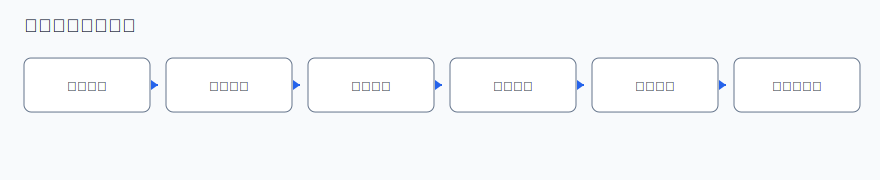

In [2]:
tu.display_tutorial_header(
    day=5,
    title='局部代理模型',
    subtitle='从有限实验轨迹中训练一个局部 world model，并用它推荐下一轮实验。',
    focus=[
        '特征表构建',
        '随机森林 surrogate',
        '不确定性直觉',
        '候选实验推荐',
    ],
    deliverables=[
        '一张训练数据表',
        '一个 surrogate 预测结果',
        '三个 final assay 候选条件',
    ],
    project_link='你的 agent card 应该说明模型学到了什么、没学到什么，以及哪里可能外推失败。',
)
tu.display_course_map(5)
display(tu.workflow_svg())


In [3]:
tu.display_api_card()

## 第 5 天检查点

完成本 notebook 后，请确认你已经留下这些证据：

- 一张来自自己实验的轨迹表或 JSONL 文件
- 一张由自己实验数据生成的图
- 一个有化工意义的机制假设
- 一个下一轮实验建议
- 一条关于 GPT 或其他助手使用方式的记录


,recipe_index,temperature_C,time_h,initial_concentration_M,catalyst,solvent,yield,risk,score
0,0,154.7202,1.8595,1.6740,cat_d,acetonitrile,0.0000,0.5217,0.0000
1,1,56.3104,5.5900,1.6993,cat_c,toluene,0.5215,0.2838,0.3385
2,2,139.0399,2.8712,1.1939,cat_d,toluene,0.0038,0.4409,0.0000
3,3,152.0126,1.3737,1.5166,cat_b,toluene,0.0077,0.5200,0.0000
4,4,67.1337,6.8626,0.6820,cat_a,acetonitrile,0.7605,0.1516,0.5684
5,5,78.6969,2.4389,1.2511,cat_c,acetonitrile,0.3141,0.2493,0.2082
6,6,58.5310,2.1858,1.7528,cat_b,ethanol,0.2135,0.2538,0.1203
7,7,57.9298,1.3101,0.5729,cat_c,acetonitrile,0.3478,0.1278,0.2680
8,8,140.5077,6.2642,0.7451,cat_b,ethanol,0.0175,0.3344,0.0000
9,9,92.5437,4.7002,0.8092,cat_b,water,0.3101,0.1502,0.2229


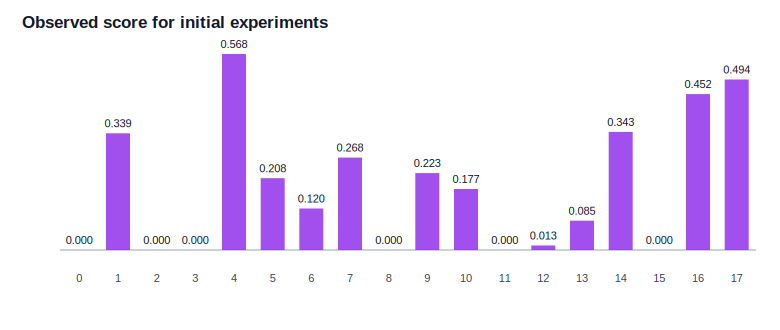

In [5]:
from chemworld.core.actions import action_to_vector

recipes = tu.sample_recipes(seed=10, count=18)
rows = []
for index, recipe in enumerate(recipes):
    result = tu.run_recipe(recipe, seed=100 + index)
    result["recipe_index"] = index
    rows.append(result)

train_df = pd.DataFrame(rows)
display(
    train_df[
        [
            "recipe_index",
            "temperature_C",
            "time_h",
            "initial_concentration_M",
            "catalyst",
            "solvent",
            "yield",
            "risk",
            "score",
        ]
    ].head(10)
)
display(
    tu.bar_svg(
        train_df["recipe_index"].astype(str).tolist(),
        train_df["score"].astype(float).tolist(),
        title="Observed score for initial experiments",
        color="#9333ea",
    )
)

,observed,predicted
0,0.0000,0.0399
1,0.3385,0.2945
2,0.0000,0.0092
3,0.0000,0.0303
4,0.5684,0.4129


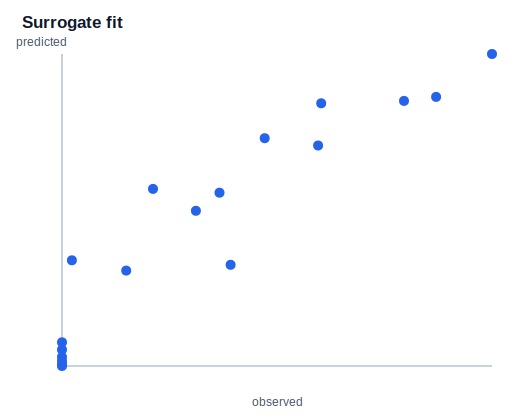

In [6]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

x_train = np.vstack([action_to_vector(recipe) for recipe in recipes])
y_train = train_df["score"].astype(float).to_numpy()

model = RandomForestRegressor(
    n_estimators=160,
    min_samples_leaf=2,
    random_state=5,
)
model.fit(x_train, y_train)

fit_df = pd.DataFrame(
    {
        "observed": y_train,
        "predicted": model.predict(x_train),
    }
)
display(fit_df.head())
display(tu.scatter_svg(fit_df, x="observed", y="predicted", title="Surrogate fit"))

In [7]:
candidates = tu.sample_recipes(seed=99, count=80)
x_candidates = np.vstack([action_to_vector(recipe) for recipe in candidates])
predicted = model.predict(x_candidates)

candidate_df = pd.DataFrame([tu.format_recipe(recipe) for recipe in candidates])
candidate_df["predicted_score"] = predicted
top_candidates = (
    candidate_df.sort_values("predicted_score", ascending=False).head(8).reset_index(drop=True)
)
display(top_candidates)

best_index = int(np.argmax(predicted))
recommended_recipe = candidates[best_index]
tu.show_json_panel("Recommended recipe", tu.format_recipe(recommended_recipe))

,temperature_C,time_h,initial_concentration_M,stirring_rpm,catalyst,solvent,predicted_score
0,53.3827,6.7449,0.5621,224.8718,cat_a,acetonitrile,0.4046
1,43.8164,5.5080,1.7152,538.0096,cat_a,toluene,0.3905
2,42.5173,3.7372,0.4435,1098.3663,cat_a,acetonitrile,0.3773
3,76.6545,5.2484,0.5826,193.5374,cat_a,acetonitrile,0.3445
4,75.8387,5.6951,0.9593,1078.8437,cat_a,ethanol,0.3178
5,63.2416,0.7845,0.5789,204.7121,cat_d,water,0.3170
6,61.5549,7.0038,0.1251,309.1689,cat_d,toluene,0.3143
7,60.0481,0.8998,0.2903,542.1833,cat_d,ethanol,0.3130


In [8]:
gpt_prompt_template = {
    "role": "You propose chemically plausible next experiments.",
    "return_format": [
        {
            "temperature": "degC in [40, 160]",
            "time": "h in [0.25, 8.0]",
            "initial_concentration": "mol/L in [0.10, 2.00]",
            "stirring_speed": "rpm in [100, 1200]",
            "catalyst": "integer 0..3",
            "solvent": "integer 0..3",
            "rationale": "one sentence",
        }
    ],
    "validator": "ChemWorld canonicalize_action plus final assay replay",
}
tu.show_json_panel("Structured GPT proposal template", gpt_prompt_template)

,source,score,yield,risk
0,best_initial_observed,0.5684,0.7605,0.1516
1,surrogate_recommendation,0.3910,0.5131,0.1260


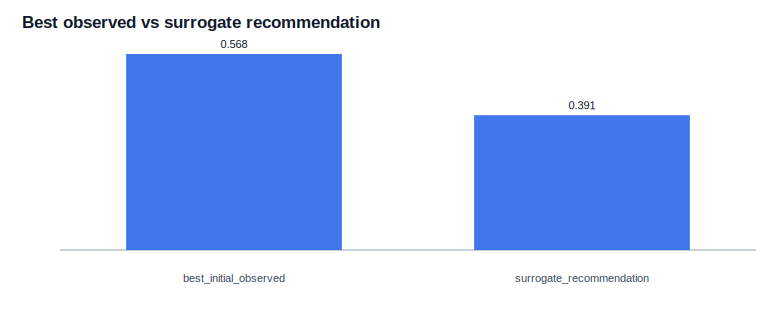

In [9]:
recommended_result = tu.run_recipe(recommended_recipe, seed=777)
best_initial = train_df.iloc[int(train_df["score"].to_numpy().argmax())]
comparison = pd.DataFrame(
    [
        {
            "source": "best_initial_observed",
            "score": float(train_df["score"].max()),
            "yield": float(best_initial["yield"]),
            "risk": float(best_initial["risk"]),
        },
        {
            "source": "surrogate_recommendation",
            "score": float(recommended_result["score"]),
            "yield": float(recommended_result["yield"]),
            "risk": float(recommended_result["risk"]),
        },
    ]
)
display(comparison)
display(
    tu.bar_svg(
        comparison["source"].tolist(),
        comparison["score"].tolist(),
        title="Best observed vs surrogate recommendation",
        color="#2563eb",
    )
)

## 当天练习

surrogate model 不是 oracle。请回答：

- 它最容易在哪些区域外推失败？
- 如果你还有 6 次实验预算，会保守 exploitation，还是探索高不确定区域？
- 安全风险应作为预测目标、约束，还是惩罚项？


## 课后反思

请用两三句话回答下面的问题，并把答案写进当天的实验日志。


In [10]:
tu.display_reflection_box(
    [
        'surrogate 在哪里最容易过度自信？',
        '你会如何用新实验降低模型不确定性？',
    ]
)
